# Example code for Phase-Field sintering simulation

The kinetic equations are 

$$\frac{\partial \rho}{\partial t} = \nabla \cdot M \nabla \frac{\delta \mathcal{F}}{\delta \rho} - \nabla \cdot \big( \rho \vec{v} \big) = \nabla \cdot M \nabla \bigg(\frac{\partial f}{\partial \rho} - \varepsilon_\rho \nabla^2 \rho \bigg) - \nabla \cdot \big(\rho \vec{v}\big),$$

and 

$$\frac{\partial \eta_i}{\partial t} = -L \frac{\delta \mathcal{F}}{\delta \eta_i} - \nabla \cdot \big( \eta_i \vec{v} \big) = - L \bigg( \frac{\partial f}{\partial \eta_i} - \varepsilon_\eta \nabla^2 \eta_i \bigg) - \nabla \cdot \big( \eta_i \vec{v} \big),$$


where 

$$\frac{\partial f}{\partial \rho} = 2 \alpha \rho \big(1-\rho\big) \big( 1- 2\rho \big) + \beta \bigg[ 2 \rho -6\sum_i \eta_i^2 + 4 \sum_i \eta_i^3 \bigg],$$

and 

$$\frac{\partial f}{\partial \eta_i} = \beta\bigg[ 12 \big(1-\rho \big) \eta_i -12 \big(2-\rho \big) \eta_i^2 + 12 \eta_i \bigg(\sum_i \eta_i^2 \bigg) \bigg].$$

The cell below sets up simulation parameters and data arrays.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# numerical parameters
Ny = 100
Nx = 100
dx = 1.0
dt = 0.001

# material parameters
A = 16.0
B = 1.0
Mvol = 0.01
Mvap = 0.001
Msurf = 4.0
Mgb = 0.4
L = 10.0
rho0 = 0.9816
C0 = 0.14
kap = 100.0
epsr = 10.0
epse = 1.0
mt = 500.0
mr = 1.0

# arrays
rho  = np.zeros((Ny, Nx))
Mob  = np.zeros((Ny, Nx))
hoP  = np.zeros((Ny, Nx))
LpR  = np.zeros((Ny, Nx))
muR  = np.zeros((Ny, Nx))
rhoV = np.zeros((Ny, Nx, 2))
dvgR = np.zeros((Ny, Nx))

eta  = np.zeros((Ny, Nx, 3))
LpE  = np.zeros((Ny, Nx, 3))
muE  = np.zeros((Ny, Nx, 3))
dvgE = np.zeros((Ny, Nx, 3))

SQoE = np.zeros((Ny, Nx))
CBoE = np.zeros((Ny, Nx))

# forces
dFp1 = np.zeros((Ny, Nx, 2))
dFp2 = np.zeros((Ny, Nx, 2))
dFp3 = np.zeros((Ny, Nx, 2))

# torques
dTq1 = np.zeros((Ny, Nx, 2))
dTq2 = np.zeros((Ny, Nx, 2))
dTq3 = np.zeros((Ny, Nx, 2))

# rigid body motion velocities
Vt1 = np.zeros((Ny, Nx, 2))
Vr1 = np.zeros((Ny, Nx, 2))

Vt2 = np.zeros((Ny, Nx, 2))
Vr2 = np.zeros((Ny, Nx, 2))

Vt3 = np.zeros((Ny, Nx, 2))
Vr3 = np.zeros((Ny, Nx, 2))


gdE1 = np.zeros((Ny, Nx, 2))
gdE2 = np.zeros((Ny, Nx, 2))
gdE3 = np.zeros((Ny, Nx, 2))

Vadv = np.zeros((Ny, Nx, 2))


Let's create an initial condition with 3 particles.

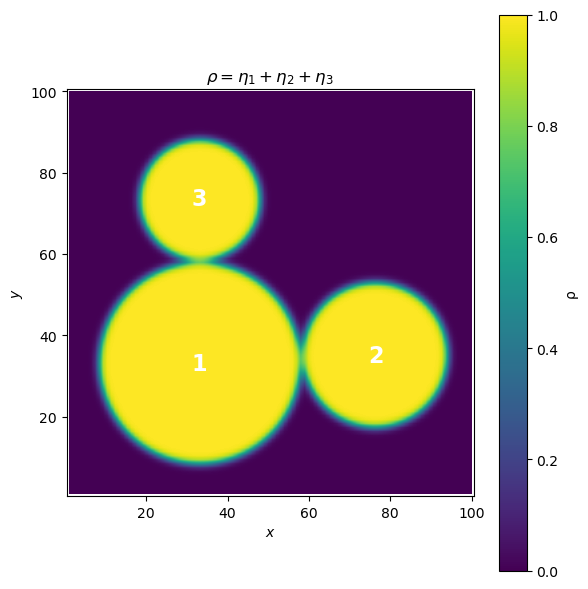

In [3]:
# %% meshgrid equivalent to: [Xmsh Ymsh] = meshgrid(1:Ny, 1:Nx);
# We want arrays of shape (Ny, Nx) with i in rows (1..Ny), j in cols (1..Nx)
I, J = np.meshgrid(np.arange(1, Ny+1), np.arange(1, Nx+1), indexing='ij')

# %% initial conditions (vectorized)
# particle 1
rad1 = np.sqrt((I - 33.0)**2 + (J - 33.0)**2)
eta[:, :, 0] = 0.5 * (1.0 - np.tanh((rad1 - 25.0) / 1.0))

# particle 2
rad2 = np.sqrt((I - 35.0)**2 + (J - 76.5)**2)
eta[:, :, 1] = 0.5 * (1.0 - np.tanh((rad2 - 18.0) / 1.0))

# particle 3
rad3 = np.sqrt((I - 73.5)**2 + (J - 33.0)**2)
eta[:, :, 2] = 0.5 * (1.0 - np.tanh((rad3 - 15.0) / 1.0))

# rho = sum over the three etas
rho[:, :] = np.sum(eta, axis=2)

# %% plotting (MATLAB: surf(pln); view(2); shading interp)
pln = rho.copy()

plt.figure(figsize=(6, 6))
# imshow gives a smooth 2D “surface” view akin to view(2) + shading interp
# extent makes axes run from 1..Nx and 1..Ny like MATLAB indices
im = plt.imshow(
    pln,
    origin='lower',
    extent=[1, Nx, 1, Ny],
    interpolation='bilinear',   # similar to 'shading interp'
    cmap='viridis',
    aspect='equal'              # akin to pbaspect square in x–y
)
plt.colorbar(im, label='ρ')

plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'$\rho = \eta_1 + \eta_2 + \eta_3$')

# Annotations 
X = [33.0, 76.5, 33.0]
Y = [33.0, 35.0, 73.5]
for n, (xv, yv) in enumerate(zip(X, Y), start=1):
    plt.text(xv, yv, f'{n}', fontsize=16, ha='center', va='center',
             color='w', weight='bold')

# here indices go 1..Nx, 1..Ny, so:
plt.xlim(0.5, Nx + 0.5)
plt.ylim(0.5, Ny + 0.5)

plt.grid(False)
plt.box(True)
plt.tight_layout()
plt.show()

The code below implements the phase-field sintering simulations.

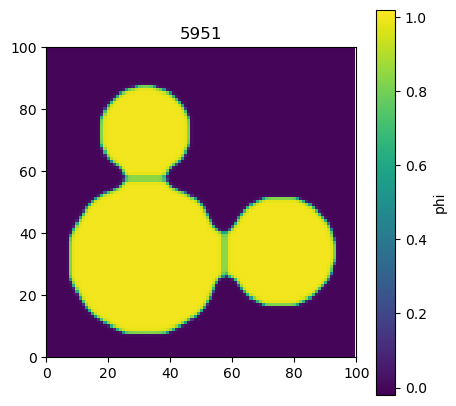

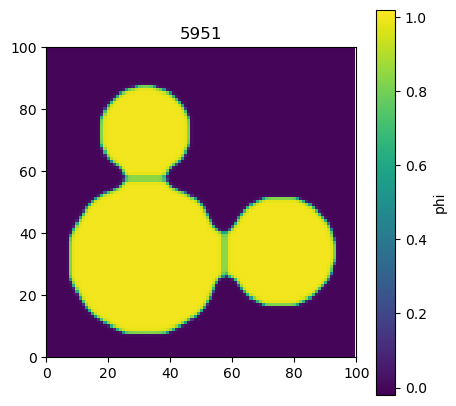

In [7]:
from IPython.display import display, clear_output
import time

val = np.sum(eta[:,:,:]**2,axis=2)
vmin, vmax = -0.02, 1.02   # set to what you want

fig, ax = plt.subplots(figsize=(5,5))
im = ax.imshow(val, origin='upper', interpolation='nearest',
               vmin=vmin, vmax=vmax, cmap='viridis')   # <- caxis via vmin/vmax
cbar = fig.colorbar(im, ax=ax, label='phi')            # <- colorbar once
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, Nx)
ax.set_ylim(0, Ny)




# convenient interior slice
ii = slice(1, -1)
jj = slice(1, -1)

Xmsh, Ymsh = np.mgrid[1:Ny+1, 1:Nx+1]

# time evolution
for it in range(6001):

    # ---- volumes and centers of the three grains ----
    vlm = np.sum(eta[ii, jj, :], axis=(0, 1))  # shape (3,)

    X = np.sum(Xmsh[ii, jj, None] * eta[ii, jj, :], axis=(0, 1)) / vlm
    Y = np.sum(Ymsh[ii, jj, None] * eta[ii, jj, :], axis=(0, 1)) / vlm

    # ---- gradients of eta_k (central differences) ----
    # Note: index 0 = x-component (columns), index 1 = y-component (rows), matching your MATLAB layout
    # gdE1
    gdE1[ii, jj, 1] = (eta[2:, jj, 0] - eta[:-2, jj, 0]) / (2.0 * dx)   # d/dy
    gdE1[ii, jj, 0] = (eta[ii, 2:, 0] - eta[ii, :-2, 0]) / (2.0 * dx)   # d/dx
    # gdE2
    gdE2[ii, jj, 1] = (eta[2:, jj, 1] - eta[:-2, jj, 1]) / (2.0 * dx)
    gdE2[ii, jj, 0] = (eta[ii, 2:, 1] - eta[ii, :-2, 1]) / (2.0 * dx)
    # gdE3
    gdE3[ii, jj, 1] = (eta[2:, jj, 2] - eta[:-2, jj, 2]) / (2.0 * dx)
    gdE3[ii, jj, 0] = (eta[ii, 2:, 2] - eta[ii, :-2, 2]) / (2.0 * dx)

    # ==== forces/torques & velocities ====
    # Helper: interior views
    rho_in  = rho[ii, jj]
    Xm_in   = Xmsh[ii, jj]
    Ym_in   = Ymsh[ii, jj]
    eta1_in = eta[ii, jj, 0]
    eta2_in = eta[ii, jj, 1]
    eta3_in = eta[ii, jj, 2]

    # ---------- particle 1 ----------
    dFp1[ii, jj, :] = 0.0
    # masks for contacts (> C0)
    m12 = (eta1_in * eta2_in) > C0
    m13 = (eta1_in * eta3_in) > C0

    # x-component
    dFp1_x = np.zeros_like(rho_in)
    dFp1_x[m12] += kap * (rho_in[m12] - rho0) * (gdE1[ii, jj, 0][m12] - gdE2[ii, jj, 0][m12])
    dFp1_x[m13] += kap * (rho_in[m13] - rho0) * (gdE1[ii, jj, 0][m13] - gdE3[ii, jj, 0][m13])

    # y-component
    dFp1_y = np.zeros_like(rho_in)
    dFp1_y[m12] += kap * (rho_in[m12] - rho0) * (gdE1[ii, jj, 1][m12] - gdE2[ii, jj, 1][m12])
    dFp1_y[m13] += kap * (rho_in[m13] - rho0) * (gdE1[ii, jj, 1][m13] - gdE3[ii, jj, 1][m13])

    dFp1[ii, jj, 0] = dFp1_x
    dFp1[ii, jj, 1] = dFp1_y

    F1x = np.sum(dFp1[ii, jj, 0])
    F1y = np.sum(dFp1[ii, jj, 1])

    dTq1[ii, jj, 0] = (Xm_in - X[0]) * dFp1_y - (Ym_in - Y[0]) * dFp1_x
    Tq1 = np.sum(dTq1[ii, jj, 0])

    # translational velocity
    Vt1[ii, jj, 0] = (mt / vlm[0]) * F1x * eta1_in
    Vt1[ii, jj, 1] = (mt / vlm[0]) * F1y * eta1_in

    # rotational velocity  (NOTE: fixed a likely typo; this should write into Vr1, not Vr2)
    Vr1[ii, jj, 0] = - (mr / vlm[0]) * (Ym_in - Y[0]) * Tq1
    Vr1[ii, jj, 1] = - (mr / vlm[0]) * (Xm_in - X[0]) * Tq1

    # ---------- particle 2 ----------
    dFp2[ii, jj, :] = 0.0
    m21 = (eta2_in * eta1_in) > C0
    m23 = (eta2_in * eta3_in) > C0

    dFp2_x = np.zeros_like(rho_in)
    dFp2_x[m21] += kap * (rho_in[m21] - rho0) * (gdE2[ii, jj, 0][m21] - gdE1[ii, jj, 0][m21])
    dFp2_x[m23] += kap * (rho_in[m23] - rho0) * (gdE2[ii, jj, 0][m23] - gdE3[ii, jj, 0][m23])

    dFp2_y = np.zeros_like(rho_in)
    dFp2_y[m21] += kap * (rho_in[m21] - rho0) * (gdE2[ii, jj, 1][m21] - gdE1[ii, jj, 1][m21])
    dFp2_y[m23] += kap * (rho_in[m23] - rho0) * (gdE2[ii, jj, 1][m23] - gdE3[ii, jj, 1][m23])

    dFp2[ii, jj, 0] = dFp2_x
    dFp2[ii, jj, 1] = dFp2_y

    F2x = np.sum(dFp2[ii, jj, 0])
    F2y = np.sum(dFp2[ii, jj, 1])

    dTq2[ii, jj, 0] = (Xm_in - X[1]) * dFp2_y - (Ym_in - Y[1]) * dFp2_x
    Tq2 = np.sum(dTq2[ii, jj, 0])

    Vt2[ii, jj, 0] = (mt / vlm[1]) * F2x * eta2_in
    Vt2[ii, jj, 1] = (mt / vlm[1]) * F2y * eta2_in

    Vr2[ii, jj, 0] = - (mr / vlm[1]) * (Ym_in - Y[1]) * Tq2
    Vr2[ii, jj, 1] = - (mr / vlm[1]) * (Xm_in - X[1]) * Tq2

    # ---------- particle 3 ----------
    dFp3[ii, jj, :] = 0.0
    m31 = (eta3_in * eta1_in) > C0
    m32 = (eta3_in * eta2_in) > C0

    dFp3_x = np.zeros_like(rho_in)
    dFp3_x[m31] += kap * (rho_in[m31] - rho0) * (gdE3[ii, jj, 0][m31] - gdE1[ii, jj, 0][m31])
    dFp3_x[m32] += kap * (rho_in[m32] - rho0) * (gdE3[ii, jj, 0][m32] - gdE2[ii, jj, 0][m32])

    dFp3_y = np.zeros_like(rho_in)
    dFp3_y[m31] += kap * (rho_in[m31] - rho0) * (gdE3[ii, jj, 1][m31] - gdE1[ii, jj, 1][m31])
    dFp3_y[m32] += kap * (rho_in[m32] - rho0) * (gdE3[ii, jj, 1][m32] - gdE2[ii, jj, 1][m32])

    dFp3[ii, jj, 0] = dFp3_x
    dFp3[ii, jj, 1] = dFp3_y

    F3x = np.sum(dFp3[ii, jj, 0])
    F3y = np.sum(dFp3[ii, jj, 1])

    dTq3[ii, jj, 0] = (Xm_in - X[2]) * dFp3_y - (Ym_in - Y[2]) * dFp3_x
    Tq3 = np.sum(dTq3[ii, jj, 0])

    Vt3[ii, jj, 0] = (mt / vlm[2]) * F3x * eta3_in
    Vt3[ii, jj, 1] = (mt / vlm[2]) * F3y * eta3_in

    Vr3[ii, jj, 0] = - (mr / vlm[2]) * (Ym_in - Y[2]) * Tq3
    Vr3[ii, jj, 1] = - (mr / vlm[2]) * (Xm_in - X[2]) * Tq3

    # ---- overall advection velocity Vadv ----
    Vadv[ii, jj, :] = (Vt1[ii, jj, :] + Vr1[ii, jj, :] + Vt2[ii, jj, :] + Vr2[ii, jj, :] +
        Vt3[ii, jj, :] + Vr3[ii, jj, :])
    
    # BC for Vadv (copy from neighbors)
    Vadv[0, jj, :]      = Vadv[1, jj, :]
    Vadv[-1, jj, :]     = Vadv[-2, jj, :]
    Vadv[:, 0, :]       = Vadv[:, 1, :]
    Vadv[:, -1, :]      = Vadv[:, -2, :]

    # ---- mobility for rho ----
    r = rho[ii, jj]
    hoP[ii, jj] = (r**3) * (10.0 - 15.0*r + 6.0*r*r)
    Mob[ii, jj] = (Mvol*hoP[ii, jj] + Mvap*(1.0 - hoP[ii, jj]) + Msurf*r*(1.0 - r) +
        Mgb*(eta[ii, jj, 0]*eta[ii, jj, 1] +
             eta[ii, jj, 0]*eta[ii, jj, 2] +
             eta[ii, jj, 1]*eta[ii, jj, 2]) + 0.05)
    
    # BC for Mob
    Mob[0, jj]   = Mob[1, jj]
    Mob[-1, jj]  = Mob[-2, jj]
    Mob[:, 0]    = Mob[:, 1]
    Mob[:, -1]   = Mob[:, -2]

    # sums of eta^2 and eta^3
    SQoE[ii, jj] = np.sum(eta[ii, jj, :]**2, axis=2)
    CBoE[ii, jj] = np.sum(eta[ii, jj, :]**3, axis=2)

    # ---- chemical potential muR ----
    r = rho[ii, jj]
    muR[ii, jj] = (A*2.0*(r*(1.0 - r))*(1.0 - 2.0*r) +
        B*(2.0*r - 6.0*SQoE[ii, jj] + 4.0*CBoE[ii, jj]))

    # Laplacian of rho
    LpR[ii, jj] = (1.0 / dx**2) * (
        (rho[2:, jj] - rho[ii, jj]) - (rho[ii, jj] - rho[:-2, jj]) +
        (rho[ii, 2:] - rho[ii, jj]) - (rho[ii, jj] - rho[ii, :-2]))

    muR[ii, jj] = muR[ii, jj] - epsr * LpR[ii, jj]
    # BC for muR
    muR[0, jj]   = muR[1, jj]
    muR[-1, jj]  = muR[-2, jj]
    muR[:, 0]    = muR[:, 1]
    muR[:, -1]   = muR[:, -2]

    # ---- Laplacian of muR with mobility weights (discrete div(M∇mu)) ----
    LpR[ii, jj] = (0.5 / dx**2) * (
        (Mob[2:, jj] + Mob[ii, jj]) * (muR[2:, jj] - muR[ii, jj]) -
        (Mob[ii, jj] + Mob[:-2, jj]) * (muR[ii, jj] - muR[:-2, jj]) +
        (Mob[ii, 2:] + Mob[ii, jj]) * (muR[ii, 2:] - muR[ii, jj]) -
        (Mob[ii, jj] + Mob[ii, :-2]) * (muR[ii, jj] - muR[ii, :-2]))

    # ---- advection divergence for rho ----
    rhoV[:, :, 0] = rho * Vadv[:, :, 0]
    rhoV[:, :, 1] = rho * Vadv[:, :, 1]

    dvgR[ii, jj] = (
        (rhoV[2:, jj, 1] - rhoV[:-2, jj, 1]) / (2.0 * dx) +
        (rhoV[ii, 2:, 0] - rhoV[ii, :-2, 0]) / (2.0 * dx))

    # ---- chemical potentials and advection for eta_k ----
    for k in range(3):
        ek = eta[ii, jj, k]
        muE[ii, jj, k] = B * (12.0 * (1.0 - r) * ek
            - 12.0 * (2.0 - r) * (ek**2) + 12.0 * SQoE[ii, jj] * ek)

        # Laplacian of eta_k
        LpE[ii, jj, k] = (1.0 / dx**2) * (
            (eta[2:, jj, k] - eta[ii, jj, k]) - (eta[ii, jj, k] - eta[:-2, jj, k]) +
            (eta[ii, 2:, k] - eta[ii, jj, k]) - (eta[ii, jj, k] - eta[ii, :-2, k]))

        # advection divergence for eta_k
        rhoV[:, :, 0] = eta[:, :, k] * Vadv[:, :, 0]
        rhoV[:, :, 1] = eta[:, :, k] * Vadv[:, :, 1]
        dvgE[ii, jj, k] = (
            (rhoV[2:, jj, 1] - rhoV[:-2, jj, 1]) / (2.0 * dx) +
            (rhoV[ii, 2:, 0] - rhoV[ii, :-2, 0]) / (2.0 * dx))

    muE[ii, jj, :] = muE[ii, jj, :] - epse * LpE[ii, jj, :]

    # ---- Euler time update ----
    rho[ii, jj] = rho[ii, jj] + dt * LpR[ii, jj] - dt * dvgR[ii, jj]
    # BC for rho
    rho[0, jj]   = rho[1, jj]
    rho[-1, jj]  = rho[-2, jj]
    rho[:, 0]    = rho[:, 1]
    rho[:, -1]   = rho[:, -2]

    for k in range(3):
        eta[ii, jj, k] = eta[ii, jj, k] - dt * muE[ii, jj, k] - dt * dvgE[ii, jj, k]
        # BC for eta_k
        eta[0, jj, k]   = eta[1, jj, k]
        eta[-1, jj, k]  = eta[-2, jj, k]
        eta[:, 0, k]    = eta[:, 1, k]
        eta[:, -1, k]   = eta[:, -2, k]



    # visualization
    if it % 50 == 1:
        val = np.sum(eta[:,:,:]**2,axis=2)
        im.set_data(val)                 # update image only
        ax.set_title(f"{it}")
        
        # Animaiton part (dosn't change)
        clear_output(wait=True) # Clear output for dynamic display
        display(fig)            # Reset display
        # fig.clear()             # Prevent overlapping and layered plots
        time.sleep(0.0002)         # Sleep for half a second to slow down the animation   